In [5]:
# read in the feature engineered data and the exact L1 baseline artifacts from notebook 01
from pathlib import Path
import pandas as pd
pd.set_option('display.max_columns', None)

ROOT = Path('/Users/jinyecai/Desktop/ML_Mortgage')
PROC = ROOT / 'processed_mortgage'
ARTIFACT_DIR = Path('/Users/jinyecai/workSpace/freddie_mortgage/model_dev/artifacts')

prepay_fe = pd.read_parquet(PROC / 'cleaned' / 'prepay_fe.parquet')
default_fe = pd.read_parquet(PROC / 'cleaned' / 'default_fe.parquet')

l1_metrics_path = ARTIFACT_DIR / 'l1_regularized_metrics_compare.csv'
l1_selected_features_path = ARTIFACT_DIR / 'l1_selected_source_features.csv'

if not l1_metrics_path.exists() or not l1_selected_features_path.exists():
    raise FileNotFoundError(
        'Missing L1 baseline artifacts from 01_Feature_Selection_and_baseline.ipynb. '
        'Please run the last cells in notebook 01 first.'
    )

l1_baseline_metrics = pd.read_csv(l1_metrics_path)
l1_selected_source_feature_df = pd.read_csv(l1_selected_features_path)


def load_selected_source_features(outcome: str) -> list[str]:
    feature_list = (
        l1_selected_source_feature_df.loc[
            l1_selected_source_feature_df['outcome'].eq(outcome),
            ['feature_order', 'source_feature'],
        ]
        .sort_values('feature_order')
        ['source_feature']
        .tolist()
    )
    if not feature_list:
        raise ValueError(f'No selected source features found for outcome={outcome!r}')
    return feature_list


prepay_var_list = load_selected_source_features('prepay')
default_var_list = load_selected_source_features('default')


In [13]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler, OneHotEncoder, SplineTransformer


def evaluate_binary_predictions(y_true, y_score) -> dict:
    y_score_clipped = np.clip(y_score, 1e-12, 1 - 1e-12)
    return {
        'test_event_rate': float(np.mean(y_true)),
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'log_loss': float(log_loss(y_true, y_score_clipped, labels=[0, 1])),
        'brier_score': float(brier_score_loss(y_true, y_score)),
    }


def build_selected_var_train_test_split(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: list[str],
    test_size: float = 0.2,
    random_state: int = 42,
):
    X = df.loc[:, feature_cols].copy()
    y = df[target_col].astype(int).copy()
    loan_ids = df['loan_id'].copy()

    loan_level_target = pd.DataFrame({
        'loan_id': loan_ids,
        target_col: y,
    }).groupby('loan_id')[target_col].max()

    train_loans, test_loans = train_test_split(
        loan_level_target.index,
        test_size=test_size,
        random_state=random_state,
        stratify=loan_level_target.values,
    )

    train_mask = loan_ids.isin(train_loans).to_numpy()
    test_mask = loan_ids.isin(test_loans).to_numpy()

    return (
        X.loc[train_mask].copy(),
        X.loc[test_mask].copy(),
        y.loc[train_mask].copy(),
        y.loc[test_mask].copy(),
    )


def select_spline_columns(
    X_train: pd.DataFrame,
    min_unique_to_spline: int = 11,
):
    categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

    spline_cols = []
    passthrough_numeric_cols = []

    for col in numeric_cols:
        nunique = X_train[col].nunique(dropna=True)
        if nunique >= min_unique_to_spline:
            spline_cols.append(col)
        else:
            passthrough_numeric_cols.append(col)

    return categorical_cols, spline_cols, passthrough_numeric_cols


def build_spline_model(
    X_train: pd.DataFrame,
    n_knots: int = 5,
    degree: int = 3,
    min_unique_to_spline: int = 11,
    alpha: float = 0.0001,
    random_state: int = 42,
):
    categorical_cols, spline_cols, passthrough_numeric_cols = select_spline_columns(
        X_train,
        min_unique_to_spline=min_unique_to_spline,
    )

    transformers = []
    all_numeric_cols = spline_cols + passthrough_numeric_cols

    if all_numeric_cols:
        transformers.append(
            ('num_linear', SimpleImputer(strategy='median'), all_numeric_cols)
        )

    if spline_cols:
        transformers.append((
            'num_spline',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('spline', SplineTransformer(
                    n_knots=n_knots,
                    degree=degree,
                    include_bias=False,
                    extrapolation='linear',
                    sparse_output=True,
                )),
            ]),
            spline_cols,
        ))

    if categorical_cols:
        transformers.append((
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')),
            ]),
            categorical_cols,
        ))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop',
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('scaler', MaxAbsScaler()),
        ('classifier', SGDClassifier(
            loss='log_loss',
            penalty='l2',
            alpha=alpha,
            max_iter=1000,
            tol=1e-3,
            random_state=random_state,
        )),
    ])

    feature_plan = pd.DataFrame([
        {
            'feature': col,
            'feature_type': 'categorical' if col in categorical_cols else 'numeric',
            'model_role': (
                'categorical_onehot' if col in categorical_cols else
                'linear_plus_spline' if col in spline_cols else
                'linear_only'
            ),
            'nunique_train': int(X_train[col].nunique(dropna=True)),
        }
        for col in X_train.columns
    ]).sort_values(['model_role', 'feature']).reset_index(drop=True)

    return model, feature_plan, categorical_cols, spline_cols, passthrough_numeric_cols


def build_baseline_comparison_row(
    baseline_metrics: pd.DataFrame,
    outcome: str,
):
    baseline_row = baseline_metrics.loc[baseline_metrics['outcome'].eq(outcome)].copy()
    if baseline_row.empty:
        raise ValueError(f'No baseline metrics found for outcome={outcome!r}')

    baseline_row = baseline_row.iloc[0]
    return {
        'outcome': outcome,
        'model': 'l1_baseline_from_01',
        'feature_definition': 'exact encoded features selected by L1',
        'train_rows': int(baseline_row['train_rows']),
        'test_rows': int(baseline_row['test_rows']),
        'n_model_input_features': int(baseline_row['n_selected_encoded_features']),
        'test_event_rate': float(baseline_row['test_event_rate']),
        'roc_auc': float(baseline_row['roc_auc']),
        'pr_auc': float(baseline_row['pr_auc']),
        'log_loss': float(baseline_row['log_loss']),
        'brier_score': float(baseline_row['brier_score']),
    }


def run_spline_experiment(
    df: pd.DataFrame,
    target_col: str,
    feature_cols: list[str],
    label: str,
    baseline_metrics: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42,
    n_knots: int = 5,
    degree: int = 3,
    min_unique_to_spline: int = 11,
    alpha: float = 0.0001,
):
    X_train, X_test, y_train, y_test = build_selected_var_train_test_split(
        df,
        target_col=target_col,
        feature_cols=feature_cols,
        test_size=test_size,
        random_state=random_state,
    )

    model, feature_plan, categorical_cols, spline_cols, passthrough_numeric_cols = build_spline_model(
        X_train,
        n_knots=n_knots,
        degree=degree,
        min_unique_to_spline=min_unique_to_spline,
        alpha=alpha,
        random_state=random_state,
    )

    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    metrics = evaluate_binary_predictions(y_test, y_score)
    encoded_feature_names = model.named_steps['preprocessor'].get_feature_names_out()

    spline_row = {
        'outcome': label,
        'model': 'spline_on_l1_source_vars',
        'feature_definition': 'selected source variables from L1 with spline expansion on continuous variables',
        'train_rows': int(X_train.shape[0]),
        'test_rows': int(X_test.shape[0]),
        'n_model_input_features': int(len(encoded_feature_names)),
        **metrics,
    }

    comparison_table = pd.DataFrame([
        build_baseline_comparison_row(baseline_metrics, label),
        spline_row,
    ]).round(6)

    return {
        'comparison_table': comparison_table,
        'spline_run': {
            'outcome': label,
            'pipeline': model,
            'feature_plan': feature_plan,
            'categorical_cols': categorical_cols,
            'spline_cols': spline_cols,
            'passthrough_numeric_cols': passthrough_numeric_cols,
            'metrics': metrics,
            'metrics_table': pd.DataFrame([spline_row]).round(6),
        },
    }


spline_config = {
    'n_knots': 5,
    'degree': 3,
    'min_unique_to_spline': 11,
    'alpha': 0.0001,
    'random_state': 42,
}

prepay_spline_results = run_spline_experiment(
    prepay_fe,
    target_col='y_prepay',
    feature_cols=prepay_var_list,
    label='prepay',
    baseline_metrics=l1_baseline_metrics,
    **spline_config,
)

default_spline_results = run_spline_experiment(
    default_fe,
    target_col='y_default',
    feature_cols=default_var_list,
    label='default',
    baseline_metrics=l1_baseline_metrics,
    **spline_config,
)

selected_var_model_comparison = pd.concat([
    prepay_spline_results['comparison_table'],
    default_spline_results['comparison_table'],
], ignore_index=True)

comparison_output_path = ARTIFACT_DIR / 'l1_vs_spline_model_comparison.csv'
selected_var_model_comparison.to_csv(comparison_output_path, index=False)

print('Prepay model performance:')
print(prepay_spline_results['comparison_table'].to_string(index=False))
print()
print('Default model performance:')
print(default_spline_results['comparison_table'].to_string(index=False))
print()
print('Combined performance summary:')
print(selected_var_model_comparison.to_string(index=False))
print()
print(f'Saved comparison table to {comparison_output_path}')
print()
print('Prepay spline feature plan:')
print(prepay_spline_results['spline_run']['feature_plan'].to_string(index=False))
print()
print('Default spline feature plan:')
print(default_spline_results['spline_run']['feature_plan'].to_string(index=False))


Prepay model performance:
outcome                    model                                                              feature_definition  train_rows  test_rows  n_model_input_features  test_event_rate  roc_auc   pr_auc  log_loss  brier_score
 prepay      l1_baseline_from_01                                           exact encoded features selected by L1     1430718     354444                      25         0.010797 0.983966 0.731478  0.023385     0.005932
 prepay spline_on_l1_source_vars selected source variables from L1 with spline expansion on continuous variables     1430718     354444                      77         0.010797 0.999848 0.986415  0.004439     0.000961

Default model performance:
outcome                    model                                                              feature_definition  train_rows  test_rows  n_model_input_features  test_event_rate  roc_auc   pr_auc  log_loss  brier_score
default      l1_baseline_from_01                                          

In [14]:
prepay_spline_results['comparison_table']

,outcome,model,feature_definition,train_rows,test_rows,n_model_input_features,test_event_rate,roc_auc,pr_auc,log_loss,brier_score
0,prepay,l1_baseline_from_01,exact encoded features selected by L1,1430718,354444,25,0.010797,0.983966,0.731478,0.023385,0.005932
1,prepay,spline_on_l1_source_vars,selected source variables from L1 with spline ...,1430718,354444,77,0.010797,0.999848,0.986415,0.004439,0.000961


In [15]:
default_spline_results['comparison_table']

,outcome,model,feature_definition,train_rows,test_rows,n_model_input_features,test_event_rate,roc_auc,pr_auc,log_loss,brier_score
0,default,l1_baseline_from_01,exact encoded features selected by L1,1424249,360913,17,0.000798,0.798036,0.004624,0.006101,0.000796
1,default,spline_on_l1_source_vars,selected source variables from L1 with spline ...,1424249,360913,70,0.000798,0.832383,0.012072,0.005655,0.000793


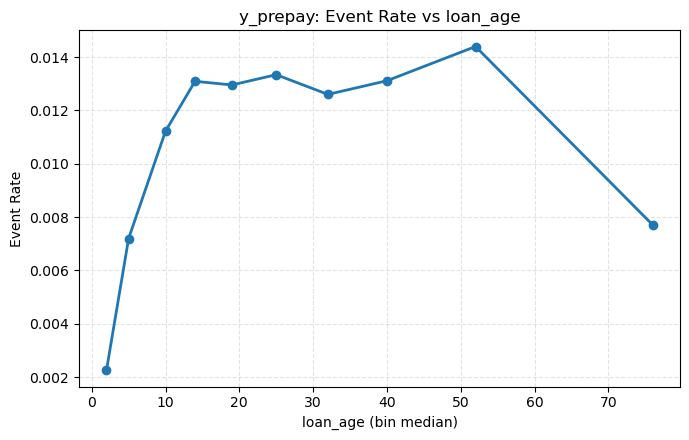

         _bin  n_obs  event_rate  x_median  log_odds
(-0.001, 3.0] 186396    0.002253       2.0 -6.093118
   (3.0, 7.0] 179945    0.007197       5.0 -4.926918
  (7.0, 12.0] 206681    0.011220      10.0 -4.478757
 (12.0, 16.0] 149126    0.013090      14.0 -4.322761
 (16.0, 22.0] 198329    0.012953      19.0 -4.333373
 (22.0, 28.0] 170642    0.013338      25.0 -4.303721
 (28.0, 35.0] 166912    0.012599      32.0 -4.361422
 (35.0, 45.0] 184653    0.013111      40.0 -4.321100
 (45.0, 60.0] 170422    0.014394      52.0 -4.226468
(60.0, 115.0] 172056    0.007707      76.0 -4.857916


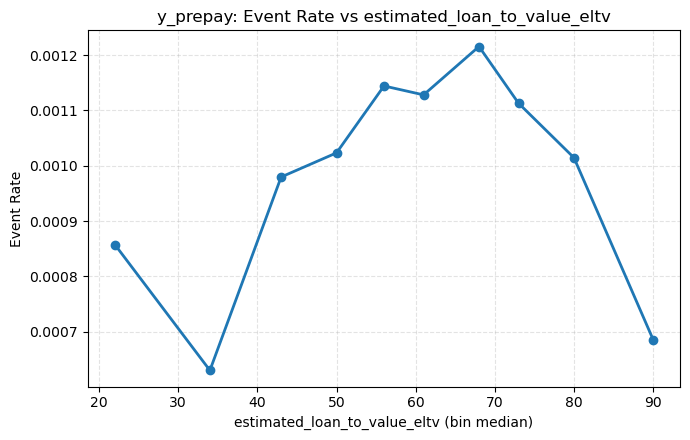

         _bin  n_obs  event_rate  x_median  log_odds
(0.999, 29.0] 170303    0.000857      22.0 -7.060870
 (29.0, 38.0] 153973    0.000630      34.0 -7.369191
 (38.0, 46.0] 183745    0.000980      43.0 -6.927367
 (46.0, 52.0] 154404    0.001023      50.0 -6.883709
 (52.0, 58.0] 159927    0.001144      56.0 -6.771842
 (58.0, 64.0] 160443    0.001128      61.0 -6.786068
 (64.0, 70.0] 162888    0.001216      68.0 -6.711335
 (70.0, 76.0] 159033    0.001113      73.0 -6.799604
 (76.0, 84.0] 154755    0.001015      80.0 -6.892338
(84.0, 441.0] 150188    0.000686      90.0 -7.284228


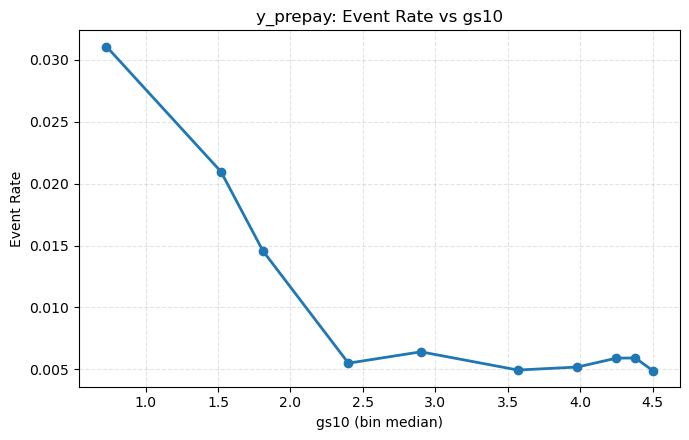

         _bin  n_obs  event_rate  x_median  log_odds
(0.619, 1.26] 190973    0.031083      0.73 -3.439520
 (1.26, 1.63] 176513    0.020979      1.52 -3.843049
 (1.63, 2.13] 182014    0.014570      1.81 -4.214092
 (2.13, 2.71] 169605    0.005501      2.40 -5.197306
 (2.71, 3.12] 179143    0.006419      2.90 -5.041982
 (3.12, 3.75] 209399    0.004947      3.57 -5.303915
  (3.75, 4.1] 152795    0.005190      3.98 -5.255826
  (4.1, 4.28] 201740    0.005909      4.25 -5.125421
 (4.28, 4.39] 151837    0.005921      4.38 -5.123341
  (4.39, 4.8] 171143    0.004908      4.50 -5.311933


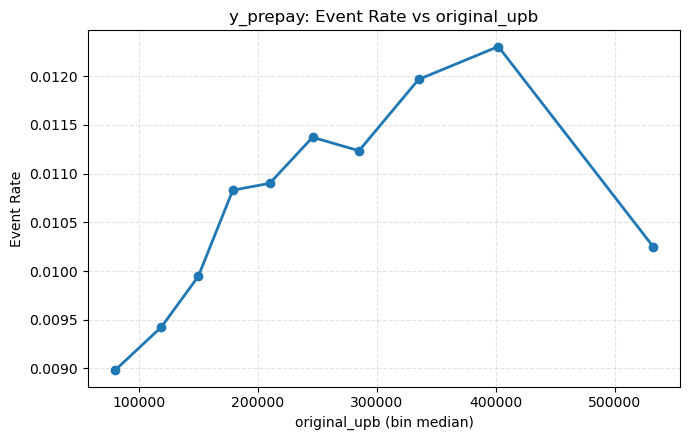

                 _bin  n_obs  event_rate  x_median  log_odds
(10999.999, 100000.0] 182175    0.008980   80000.0 -4.703693
 (100000.0, 133000.0] 175694    0.009425  119000.0 -4.654869
 (133000.0, 163000.0] 177685    0.009945  150000.0 -4.600735
 (163000.0, 195000.0] 182743    0.010829  179000.0 -4.514601
 (195000.0, 227000.0] 177251    0.010900  210000.0 -4.508051
 (227000.0, 264000.0] 180083    0.011373  246000.0 -4.465116
 (264000.0, 308000.0] 176428    0.011234  285000.0 -4.477509
 (308000.0, 366000.0] 177591    0.011966  335000.0 -4.413673
 (366000.0, 448000.0] 177673    0.012304  402000.0 -4.385492
(448000.0, 1640000.0] 177839    0.010251  532000.0 -4.570091


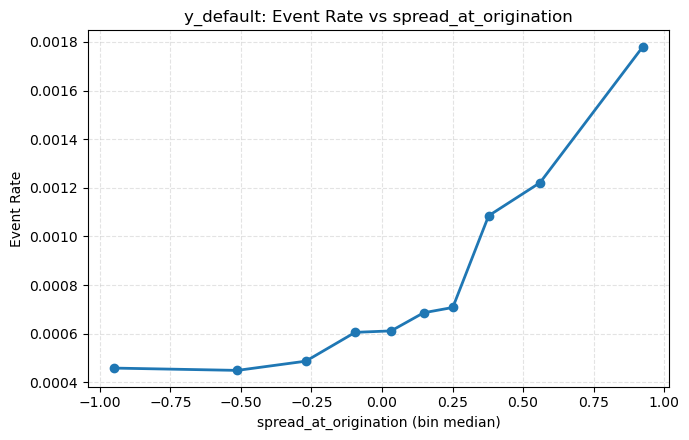

             _bin  n_obs  event_rate  x_median  log_odds
 (-3.871, -0.681] 178966    0.000458    -0.948 -7.687774
 (-0.681, -0.383] 178281    0.000449   -0.5125 -7.708641
 (-0.383, -0.192] 178772    0.000487     -0.27 -7.627472
(-0.192, -0.0375] 178443    0.000605    -0.095 -7.409288
 (-0.0375, 0.078] 178329    0.000611    0.0325 -7.399426
   (0.078, 0.187] 180835    0.000686    0.1475 -7.284373
   (0.187, 0.307] 179485    0.000708     0.251 -7.252952
    (0.307, 0.45] 176063    0.001085     0.378 -6.825238
    (0.45, 0.695] 178566    0.001221      0.56 -6.706997
   (0.695, 2.884] 177422    0.001781     0.925 -6.328761


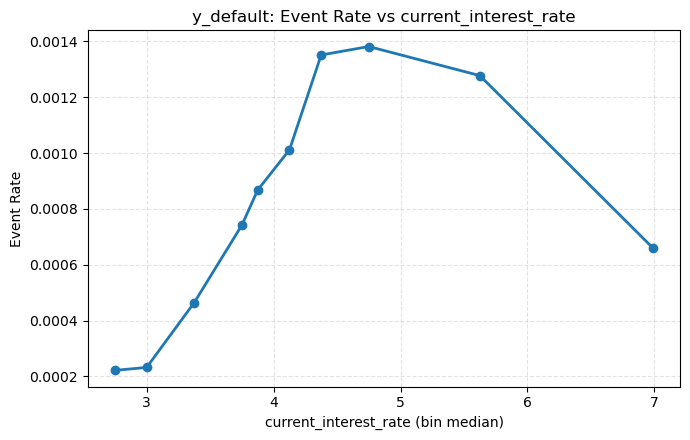

          _bin  n_obs  event_rate  x_median  log_odds
(1.749, 2.875] 230094    0.000222      2.75 -8.414196
(2.875, 3.125] 137727    0.000232       3.0 -8.367060
  (3.125, 3.5] 213112    0.000465     3.375 -7.673989
   (3.5, 3.75] 171247    0.000742      3.75 -7.205933
 (3.75, 3.999] 140598    0.000868     3.875 -7.048771
 (3.999, 4.25] 215532    0.001011     4.125 -6.895358
  (4.25, 4.56] 141359    0.001351     4.375 -6.605433
   (4.56, 5.0] 184592    0.001381      4.75 -6.583257
  (5.0, 6.375] 187115    0.001277     5.625 -6.661737
(6.375, 9.125] 163786    0.000659      6.99 -7.323525


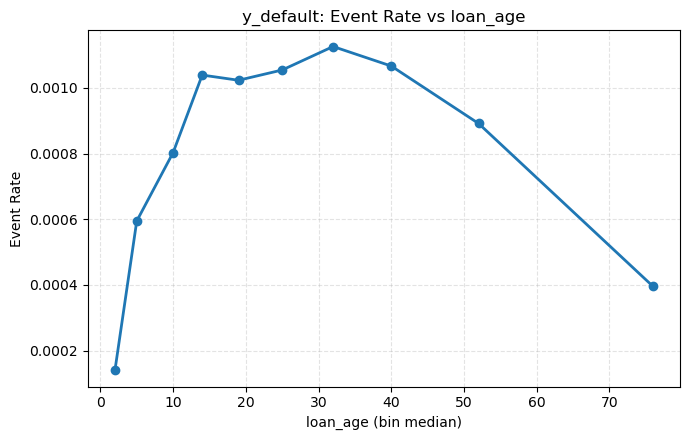

         _bin  n_obs  event_rate  x_median  log_odds
(-0.001, 3.0] 186396    0.000139       2.0 -8.877393
   (3.0, 7.0] 179945    0.000595       5.0 -7.426983
  (7.0, 12.0] 206681    0.000803      10.0 -7.126141
 (12.0, 16.0] 149126    0.001039      14.0 -6.868082
 (16.0, 22.0] 198329    0.001024      19.0 -6.883452
 (22.0, 28.0] 170642    0.001055      25.0 -6.853311
 (28.0, 35.0] 166912    0.001126      32.0 -6.787653
 (35.0, 45.0] 184653    0.001067      40.0 -6.841963
 (45.0, 60.0] 170422    0.000892      52.0 -7.021260
(60.0, 115.0] 172056    0.000395      76.0 -7.835672


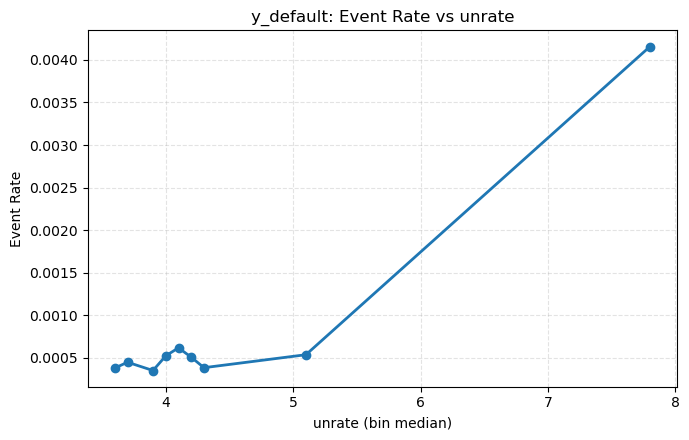

        _bin  n_obs  event_rate  x_median  log_odds
(3.399, 3.6] 421890    0.000382       3.6 -7.870714
  (3.6, 3.7] 162145    0.000450       3.7 -7.705337
  (3.7, 3.9] 269341    0.000353       3.9 -7.949504
  (3.9, 4.0]  95265    0.000525       4.0 -7.551870
  (4.0, 4.1] 161445    0.000619       4.1 -7.386130
  (4.1, 4.2] 171057    0.000509       4.2 -7.583335
  (4.2, 4.4] 173540    0.000386       4.3 -7.859085
  (4.4, 6.1] 156048    0.000538       5.1 -7.526564
 (6.1, 14.8] 174431    0.004156       7.8 -5.478948


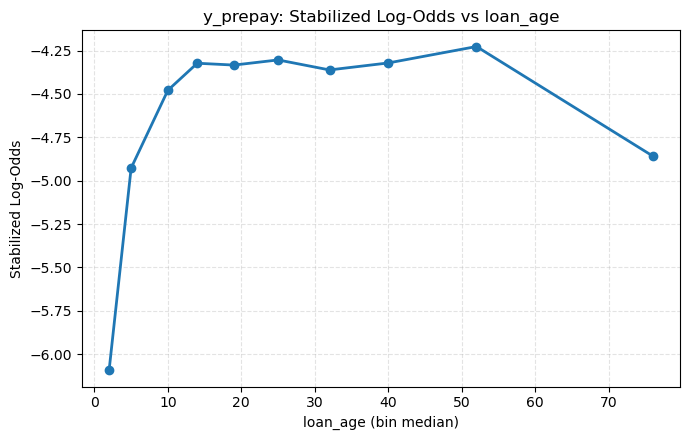

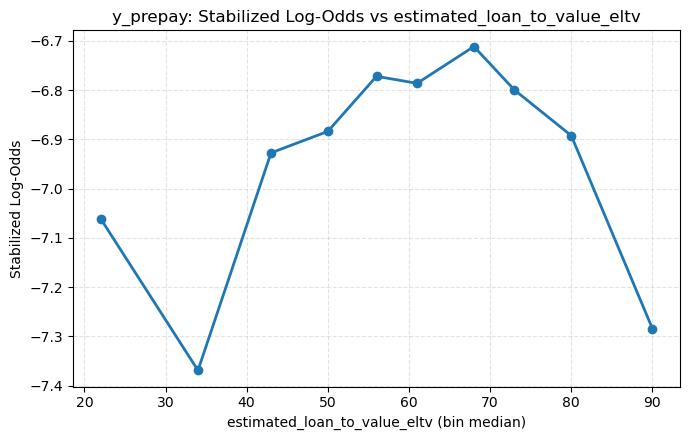

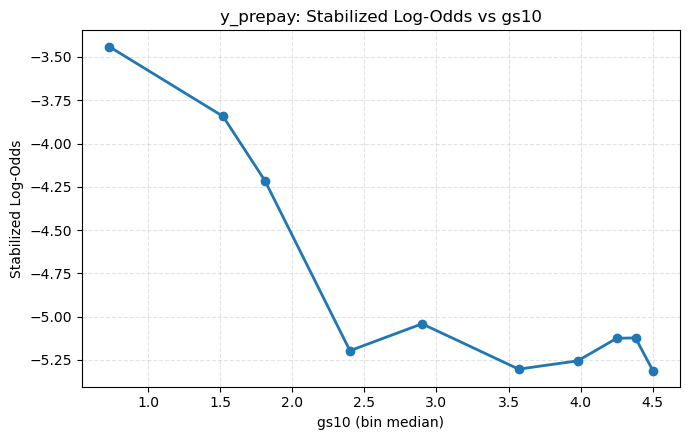

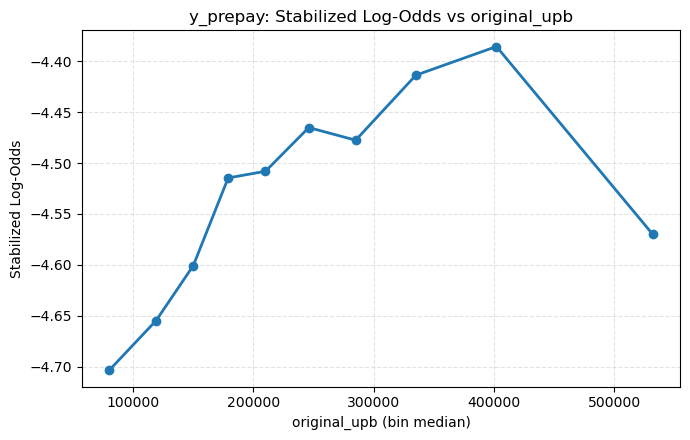

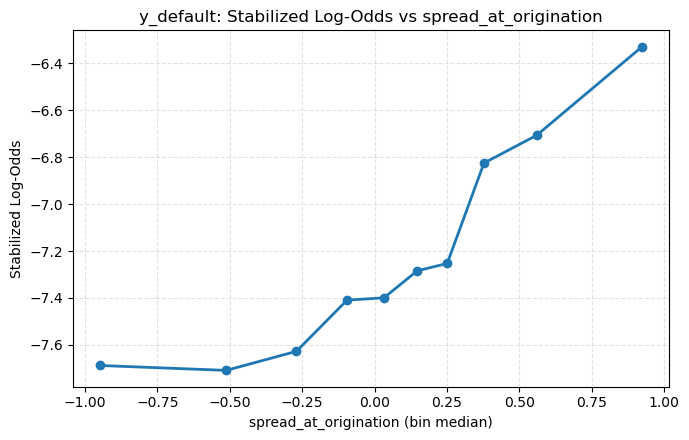

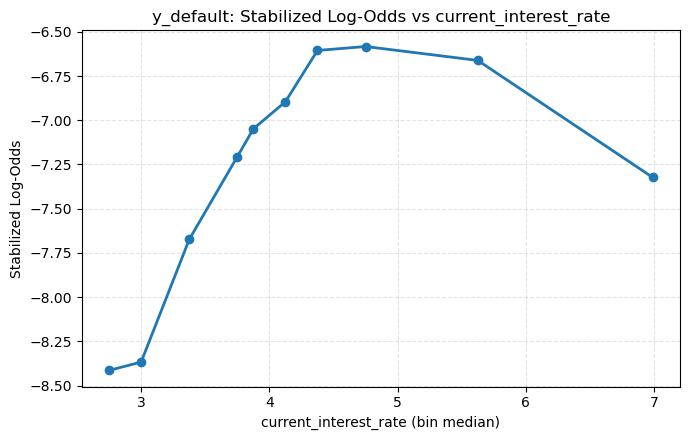

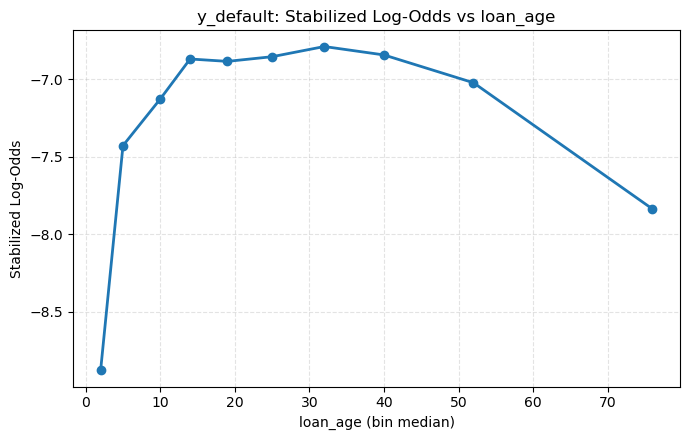

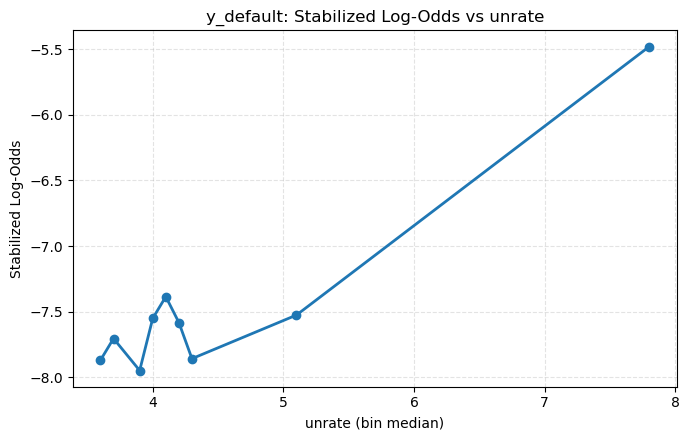

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_binned_risk(
    df: pd.DataFrame,
    target_col: str,
    x_col: str,
    n_bins: int = 10,
    use_log_odds: bool = False,
    epsilon: float = 1e-6,
    exclude_values=None,
    figsize: tuple = (7, 4.5),
):
    # Keep only needed columns
    plot_df = df[[x_col, target_col]].copy()

    # Automatically remove ELTV sentinel value
    auto_exclude_values = []
    if x_col == "estimated_loan_to_value_eltv":
        auto_exclude_values.append(999)

    # Add any user-supplied exclusions too
    if exclude_values is not None:
        auto_exclude_values.extend(np.atleast_1d(exclude_values).tolist())

    if auto_exclude_values:
        plot_df = plot_df[~plot_df[x_col].isin(auto_exclude_values)]

    # Drop missing values
    plot_df = plot_df.dropna(subset=[x_col, target_col])

    if plot_df.empty:
        raise ValueError(f"No non-missing data available for {x_col} and {target_col}.")

    plot_df[target_col] = pd.to_numeric(plot_df[target_col], errors="coerce")
    plot_df = plot_df.dropna(subset=[target_col])

    if plot_df.empty:
        raise ValueError(f"Target column {target_col} has no valid numeric values after cleaning.")

    # Equal-frequency bins
    plot_df["_bin"] = pd.qcut(plot_df[x_col], q=n_bins, duplicates="drop")

    summary_df = (
        plot_df.groupby("_bin", observed=False)
        .agg(
            n_obs=(target_col, "size"),
            event_rate=(target_col, "mean"),
            x_median=(x_col, "median"),
        )
        .reset_index()
        .sort_values("x_median")
        .reset_index(drop=True)
    )

    p = np.clip(summary_df["event_rate"].to_numpy(), epsilon, 1 - epsilon)
    summary_df["log_odds"] = np.log(p / (1 - p))

    y_col = "log_odds" if use_log_odds else "event_rate"
    y_label = "Stabilized Log-Odds" if use_log_odds else "Event Rate"

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(
        summary_df["x_median"],
        summary_df[y_col],
        marker="o",
        linewidth=2,
        markersize=6,
        color="#1f77b4",
    )
    ax.set_xlabel(f"{x_col} (bin median)")
    ax.set_ylabel(y_label)
    ax.set_title(f"{target_col}: {y_label} vs {x_col}")
    ax.grid(True, linestyle="--", alpha=0.35)
    plt.tight_layout()
    plt.show()

    return summary_df


def print_binned_summary(
    df: pd.DataFrame,
    target_col: str,
    x_col: str,
    n_bins: int = 10,
    epsilon: float = 1e-6,
    exclude_values=None,
):
    summary_df = plot_binned_risk(
        df=df,
        target_col=target_col,
        x_col=x_col,
        n_bins=n_bins,
        use_log_odds=False,
        epsilon=epsilon,
        exclude_values=exclude_values,
    )
    print(summary_df.to_string(index=False))
    return summary_df



# Example variables to inspect
prepay_vars = [
    "loan_age",
    "estimated_loan_to_value_eltv",
    "gs10",
    "original_upb",
]

default_vars = [
    "spread_at_origination",
    "current_interest_rate",
    "loan_age",
    "unrate",
]


# Optional: print summaries first for slide selection
for col in prepay_vars:
    print_binned_summary(prepay_fe, "y_prepay", col, n_bins=10)

for col in default_vars:
    print_binned_summary(default_fe, "y_default", col, n_bins=10)


# # Plot event rate curves
# for col in prepay_vars:
#     plot_binned_risk(prepay_fe, "y_prepay", col, n_bins=10, use_log_odds=False)

# for col in default_vars:
#     plot_binned_risk(default_fe, "y_default", col, n_bins=10, use_log_odds=False)


# Optional: plot stabilized log-odds curves
for col in prepay_vars:
    plot_binned_risk(prepay_fe, "y_prepay", col, n_bins=10, use_log_odds=True)

for col in default_vars:
    plot_binned_risk(default_fe, "y_default", col, n_bins=10, use_log_odds=True)
